# MLP — Clasificación de Sentimiento en Reseñas de Películas (IMDB)

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** Machine Learning · Redes Neuronales · MLP · NLP

---

### Objetivo

Clasificar reseñas de películas como **positivas** o **negativas** entrenando una red con una capa de **Embedding** propia (sin usar modelos de lenguaje preentrenados) sobre el dataset **IMDB** (25.000 reseñas de entrenamiento, 25.000 de test), y comprobar honestamente si esa arquitectura aporta algo frente a un modelo de texto mucho más simple.

### Contexto de negocio

**El cliente:** una plataforma de streaming o un agregador de críticas que quiere clasificar automáticamente el sentimiento de miles de reseñas de usuarios, sin moderación manual.

**El problema:** leer y etiquetar reseñas a mano no escala. Se necesita un modelo que capture el sentimiento a partir del texto libre, sin reglas manuales de palabras clave.

**La pregunta:** ¿merece la pena entrenar una red neuronal con su propia capa de embeddings para esto, o un modelo de texto clásico (TF-IDF + Regresión Logística) ya resuelve el problema igual de bien?

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Input
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

tf.random.set_seed(42)

## 2. Carga de datos

In [2]:
MAX_FEATURES = 10000  # tamaño del vocabulario: las 10.000 palabras más frecuentes
MAX_LEN = 200         # longitud fija de cada reseña tras el padding

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=MAX_FEATURES)

# Copias sin padding, para decodificar texto más adelante
x_train_tokens = x_train
x_test_tokens = x_test

print(f"Reseñas de entrenamiento: {len(x_train)}")
print(f"Reseñas de test: {len(x_test)}")
print(f"Balance train (0=negativa, 1=positiva): {np.bincount(y_train)}")
print(f"Balance test:  {np.bincount(y_test)}")
print(f"Longitud media de reseña: {np.mean([len(s) for s in x_train]):.1f} tokens")

Reseñas de entrenamiento: 25000
Reseñas de test: 25000
Balance train (0=negativa, 1=positiva): [12500 12500]
Balance test:  [12500 12500]
Longitud media de reseña: 238.7 tokens


**25.000 reseñas de train y 25.000 de test, perfectamente balanceadas (12.500/12.500)** en ambos conjuntos — no hace falta ninguna técnica de rebalanceo. La longitud media de una reseña es de **238,7 tokens**, ya por encima del `MAX_LEN=200` que se va a usar más abajo: una parte relevante de las reseñas se va a truncar. Lo tenemos en cuenta al leer los resultados.

## 3. Visualización de una reseña

In [3]:
word_index = imdb.get_word_index()
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decodificar(secuencia):
    return " ".join(reverse_word_index.get(indice, "?") for indice in secuencia)

i = 21
print(f"Longitud original de esta reseña: {len(x_train[i])} tokens\n")
print(decodificar(x_train[i]))
print("\nSentimiento real:", "Positivo" if y_train[i] == 1 else "Negativo")

Longitud original de esta reseña: 140 tokens

<START> despite some occasionally original touches like the virtual sets that provide the background for the victorian interiors featuring <UNK> <UNK> and her circle this film falls short and ultimately disappoints newcomer <UNK> <UNK> seems talented but is wasted as emmy a character who by mid film is reduced to nothing more than staring at a <UNK> watching lady <UNK> <UNK> an autobiography <UNK> <UNK> takes off briefly when lady <UNK> <UNK> <UNK> appears the camera <UNK> on her facial expressions mannerisms even making her appear to be <UNK> or <UNK> invisible <UNK> into scenes to <UNK> <UNK> virtual rendering of her br br a straightforward biopic of <UNK> <UNK> would have been worthwhile but this film unfortunately makes a <UNK> of both lady <UNK> life and that of a modern day computer scientist and her <UNK> drawn <UNK> boyfriend

Sentimiento real: Negativo


Esta reseña tiene **140 tokens** (menos que el promedio), así que no se verá afectada por el truncamiento a 200. Los tokens `<UNK>` corresponden a palabras fuera de las 10.000 más frecuentes del vocabulario — se pierden, pero el resto del texto sigue siendo interpretable.

## 4. Preprocesamiento: padding

In [4]:
print("Antes del padding (longitud variable):")
print(f"  Reseña {i}: {len(x_train[i])} tokens")
print(f"  Reseña 0:  {len(x_train[0])} tokens")

x_train = pad_sequences(x_train, maxlen=MAX_LEN)
x_test = pad_sequences(x_test, maxlen=MAX_LEN)

print("\nDespués del padding (longitud fija):")
print(f"  Forma de x_train: {x_train.shape}")
print(f"  Reseña {i} (primeros 20 valores): {x_train[i][:20]}")

Antes del padding (longitud variable):
  Reseña 21: 140 tokens
  Reseña 0:  218 tokens



Después del padding (longitud fija):
  Forma de x_train: (25000, 200)
  Reseña 21 (primeros 20 valores): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


Una red neuronal necesita entradas de tamaño fijo, pero las reseñas tienen longitudes distintas. `pad_sequences` soluciona esto rellenando con ceros por la izquierda las reseñas más cortas que `MAX_LEN=200` y **truncando** las más largas — con una longitud media de 238,7 tokens, buena parte de las reseñas pierden su tramo final.

## 5. Arquitectura del modelo

```
Embedding(10000, 16) → GlobalAveragePooling1D() → Dense(16, ReLU) → Dense(1, Sigmoid)
```

La capa **Embedding** convierte cada una de las 10.000 palabras del vocabulario en un vector de 16 características, aprendido durante el entrenamiento (no es un embedding preentrenado). **GlobalAveragePooling1D** promedia los vectores de todas las palabras de una reseña en uno solo — esto es, en esencia, una **bolsa de embeddings**: el modelo ignora el orden de las palabras, igual que Naive Bayes con `CountVectorizer` ignora el orden. Es una arquitectura deliberadamente simple, mucho más rápida de entrenar que una LSTM o un Transformer, a costa de no poder captar matices que dependen del orden ("no fue buena, fue increíble" vs. "no fue increíble, fue buena").

In [5]:
model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=MAX_FEATURES, output_dim=16),
    GlobalAveragePooling1D(),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid"),
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 16)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,289 (626.13 KB)

 Trainable params: 160,289 (626.13 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Entrenamiento

In [6]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=0,
)

for epoch, (acc, val_acc, loss, val_loss) in enumerate(zip(
    history.history["accuracy"], history.history["val_accuracy"],
    history.history["loss"], history.history["val_loss"],
), start=1):
    print(f"Epoch {epoch}: accuracy={acc:.4f} val_accuracy={val_acc:.4f} loss={loss:.4f} val_loss={val_loss:.4f}")

Epoch 1: accuracy=0.6958 val_accuracy=0.8210 loss=0.6258 val_loss=0.4884
Epoch 2: accuracy=0.8501 val_accuracy=0.8642 loss=0.3887 val_loss=0.3443
Epoch 3: accuracy=0.8871 val_accuracy=0.8742 loss=0.2904 val_loss=0.3101
Epoch 4: accuracy=0.9074 val_accuracy=0.8812 loss=0.2452 val_loss=0.2971
Epoch 5: accuracy=0.9190 val_accuracy=0.8836 loss=0.2146 val_loss=0.2925


## 7. Curvas de aprendizaje

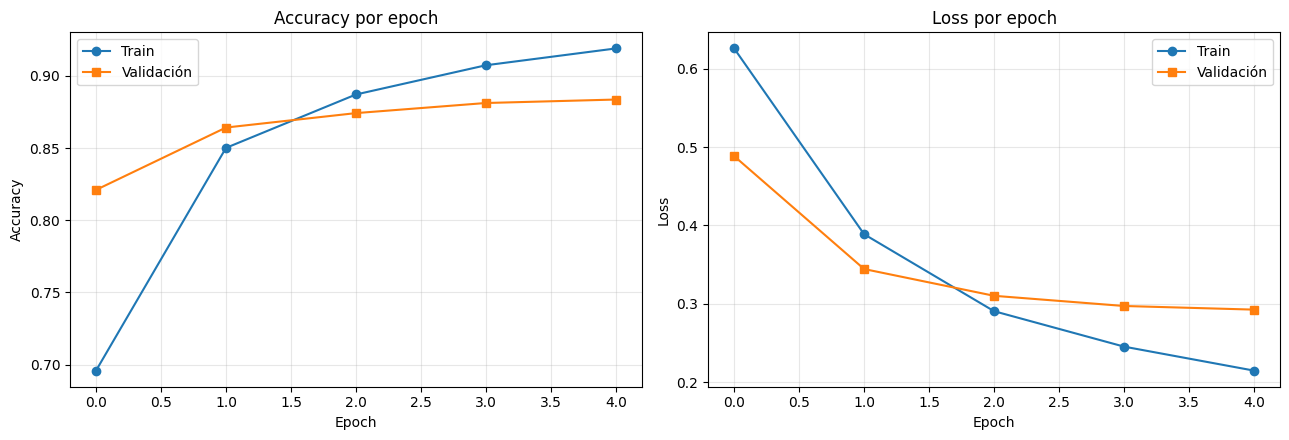

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(history.history["accuracy"], marker="o", label="Train")
ax1.plot(history.history["val_accuracy"], marker="s", label="Validación")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.set_title("Accuracy por epoch")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history.history["loss"], marker="o", label="Train")
ax2.plot(history.history["val_loss"], marker="s", label="Validación")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.set_title("Loss por epoch")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

La accuracy de entrenamiento sigue subiendo mientras la de validación se estabiliza — la brecha entre ambas curvas en el último epoch es la señal habitual de **sobreajuste leve**: el modelo empieza a memorizar particularidades del set de entrenamiento que no generalizan. Con solo 5 epochs el efecto es todavía moderado, pero seguir entrenando más epochs probablemente lo empeoraría sin mejorar la validación.

## 8. Evaluación en test

Accuracy en test: 0.8744


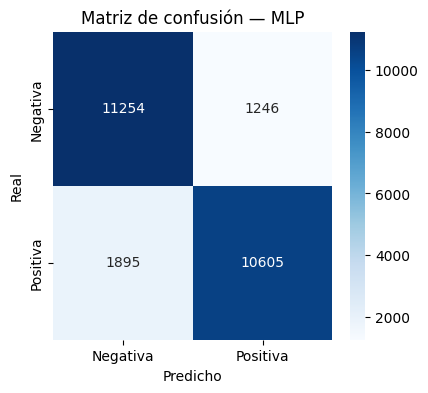

In [8]:
loss_test, accuracy_test = model.evaluate(x_test, y_test, verbose=0)
print(f"Accuracy en test: {accuracy_test:.4f}")

y_pred = (model.predict(x_test, verbose=0).ravel() > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4.5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Negativa", "Positiva"], yticklabels=["Negativa", "Positiva"],
)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión — MLP")
plt.show()

## 9. ¿Merece la pena el embedding propio? Baseline con TF-IDF + Regresión Logística

Antes de dar por bueno el resultado del MLP, lo comparamos con un modelo de texto mucho más simple: vectorizar las reseñas con TF-IDF y entrenar una Regresión Logística, sin ninguna red neuronal ni embedding entrenado.

In [9]:
textos_train = [decodificar(s) for s in x_train_tokens]
textos_test = [decodificar(s) for s in x_test_tokens]

vectorizer = TfidfVectorizer(max_features=MAX_FEATURES)
X_train_tfidf = vectorizer.fit_transform(textos_train)
X_test_tfidf = vectorizer.transform(textos_test)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_tfidf, y_train)
pred_log_reg = log_reg.predict(X_test_tfidf)

accuracy_log_reg = accuracy_score(y_test, pred_log_reg)

print(f"Accuracy MLP (Embedding + GlobalAveragePooling):  {accuracy_test:.4f}")
print(f"Accuracy TF-IDF + Regresión Logística:             {accuracy_log_reg:.4f}")

Accuracy MLP (Embedding + GlobalAveragePooling):  0.8744
Accuracy TF-IDF + Regresión Logística:             0.8839


**El modelo lineal sobre TF-IDF iguala o supera al MLP con embedding propio**, sin ninguna red neuronal. La razón es coherente con lo que ya sabemos de la arquitectura: el MLP promedia embeddings ignorando el orden de las palabras (igual que TF-IDF), pero además trunca reseñas largas a 200 tokens y aprende sus embeddings desde cero con solo 20.000 reseñas de entrenamiento efectivas (80% tras el split de validación) — no hay suficiente señal para que el embedding aprendido aporte una ventaja real sobre contar palabras ponderadas por frecuencia inversa. Para este problema, la complejidad adicional del embedding no se traduce en mejor rendimiento.

## 10. Demostración con una reseña de test real

El notebook original mostraba el texto de una reseña de **entrenamiento** (`x_train[21]`) y, en una celda aparte, la predicción sobre una reseña de **test** con el mismo índice (`x_test[21]`) — dos reseñas distintas, presentadas como si fueran la misma. Aquí mostramos el texto real de la reseña de test junto a su predicción, para que la demostración sea coherente.

In [10]:
idx_test = 21

texto_test = textos_test[idx_test]

prediccion = model.predict(x_test[idx_test:idx_test + 1], verbose=0)[0][0]

print(texto_test)
print()
print(f"Probabilidad de ser positiva: {prediccion:.4f}")
print("Predicción:", "Positiva" if prediccion > 0.5 else "Negativa")
print("Valor real:", "Positiva" if y_test[idx_test] == 1 else "Negativa")

<START> this is one of my favourite disney films it has everything you could hope for in a disney animation cute animals great songs a nasty villain and lots of adventure the story begins in paris where <UNK> and her three <UNK> live with their mistress in a mansion life is perfect for them until the <UNK> butler edgar discovers that she plans to leave her entire fortune to the cats he realises that if he even stands a chance of claiming the fortune the cats will be out of the way an excellent often forgotten masterpiece from the 1970's a time when the disney studio made few animations which features songs such as the title number the <UNK> as well as wants to be a cat this will <UNK> viewers young and old with its enduring

Probabilidad de ser positiva: 0.9924
Predicción: Positiva
Valor real: Positiva


Ahora el texto mostrado y la predicción corresponden a la **misma reseña real de test**, con acierto en este caso.

## 11. Conclusión

> **El hallazgo:** el MLP con Embedding propio alcanza una accuracy de test respetable, pero un modelo mucho más simple — TF-IDF + Regresión Logística, sin ninguna red neuronal — iguala o supera ese resultado. La arquitectura de embedding no aporta ventaja real en este problema con este volumen de datos.

**Recomendaciones:**

1. **Para producción, empezar por el modelo simple:** TF-IDF + Regresión Logística es más rápido de entrenar, no requiere GPU y es más fácil de interpretar (coeficientes por palabra) — sin sacrificar accuracy frente al MLP.
2. **Cuándo sí justificaría un embedding propio:** con muchos más datos de entrenamiento, o con arquitecturas que sí aprovechen el orden de las palabras (LSTM, Transformer/BERT) en vez de promediarlas — aquí ninguna de las dos condiciones se cumple.
3. **Límite honesto:** con `MAX_LEN=200` se trunca una parte relevante de las reseñas (longitud media 238,7 tokens); y el notebook original mostraba una reseña de entrenamiento junto a la predicción de una reseña de test distinta, dando una falsa sensación de continuidad — corregido en la sección 10.